# 07 — The Transformer Block: Normalization, Feed-Forward, and Residuals

**Lecture goal:** understand and build the three remaining ingredients — layer normalization, a feed-forward network with a nonlinear activation, and residual ("shortcut") connections — and assemble them together with the multi-head attention from notebook 06 into one complete `TransformerBlock`.

## Where we are

We have `MultiHeadAttention`, which turns a batch of token embeddings into context-aware vectors of the *same shape*. A real GPT model stacks many copies of a repeating unit — a **transformer block** — one after another (12 of them, for the smallest GPT-2). Each block needs to preserve that same-shape-in, same-shape-out property so blocks can be stacked arbitrarily. Attention alone isn't the whole block, though — three more pieces are needed to make deep stacks of it actually trainable and expressive.

## Ingredient 1: Layer Normalization

### The problem

As data flows through many stacked layers, the *scale* of the numbers (their mean and variance) can drift — some layers might output values clustered near 0, others spread out across a huge range. This instability makes training slow and unreliable: gradients (the signals used to update weights) can shrink toward zero or blow up as they pass through many such layers.

### The fix

**Layer normalization** rescales each individual token's feature vector (all 256+ numbers describing one token, at one position, in one example) to have mean 0 and variance 1, *independently* for every token. Given a vector `x`:

```
normalized = (x - mean(x)) / sqrt(variance(x) + eps)
```

`eps` is a tiny constant (like `1e-5`) added purely to avoid dividing by zero if the variance happens to be extremely small. After normalizing, we apply two small learnable vectors, **scale** (`gamma`) and **shift** (`beta`), one number per feature:

```
output = normalized * gamma + beta
```

Why re-introduce scale and shift right after just removing scale? Because forcing *every* layer's output to strictly have mean 0, variance 1 might be too restrictive for what the network actually needs to represent. `gamma` and `beta` are learned during training, so the model can recover any scale/shift it needs — but training starts from a stable, well-behaved baseline instead of wildly varying activations.

Let's see the normalization step on a toy tensor before wrapping it in a class.

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(123)
example_batch = torch.randn(2, 5)  # 2 toy examples, 5 features each
print(example_batch)
print()
print("Per-example mean:", example_batch.mean(dim=-1))
print("Per-example var: ", example_batch.var(dim=-1))

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

Per-example mean: tensor([-0.3596, -0.2606])
Per-example var:  tensor([0.2518, 0.3342])


In [2]:
mean = example_batch.mean(dim=-1, keepdim=True)
var = example_batch.var(dim=-1, keepdim=True, unbiased=False)
normalized = (example_batch - mean) / torch.sqrt(var + 1e-5)

print(normalized)
print()
print("New per-example mean (should be ~0):", normalized.mean(dim=-1))
print("New per-example var (should be ~1): ", normalized.var(dim=-1, unbiased=False))

tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]])

New per-example mean (should be ~0): tensor([-2.9802e-08,  0.0000e+00])
New per-example var (should be ~1):  tensor([1.0000, 1.0000])


(We use `keepdim=True` so `mean`/`var` keep shape `(2, 1)` instead of collapsing to `(2,)` — that way, subtracting/dividing broadcasts correctly against the original `(2, 5)` tensor, the same broadcasting idea from notebook 04.)

Now let's package this into a reusable `LayerNorm` module, matching GPT-2's design, with learnable `scale` and `shift` parameters initialized to 1 and 0 respectively (so at the very start of training, before any learning happens, `LayerNorm` behaves like plain normalization with no extra shift).

In [3]:
class LayerNorm(nn.Module):
    def __init__(self, embedding_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized + self.shift

In [4]:
layer_norm = LayerNorm(embedding_dim=5)
output = layer_norm(example_batch)
print(output)
print()
print("scale (gamma), starts at all 1s:", layer_norm.scale.data)
print("shift (beta), starts at all 0s: ", layer_norm.shift.data)

tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)

scale (gamma), starts at all 1s: tensor([1., 1., 1., 1., 1.])
shift (beta), starts at all 0s:  tensor([0., 0., 0., 0., 0.])


## Ingredient 2: A feed-forward network with a nonlinear activation

### Why we need this at all

Self-attention is built almost entirely out of matrix multiplications and weighted sums — mathematically, that's a *linear* operation (roughly speaking: no matter how many linear layers you stack, the composition is still just one big linear transformation). Real language requires modeling far more complex, non-linear relationships. We need to inject **nonlinearity** — a function that can't be reduced to "multiply by a matrix and add a constant" — between layers, and give the network some extra capacity to process each token's representation individually.

### GELU: the activation function GPT-2 uses

You may have heard of **ReLU** (`max(0, x)`) — the most common, simplest nonlinearity in deep learning: it passes positive values through unchanged and clips negative values to exactly 0. GPT-2 instead uses **GELU** (Gaussian Error Linear Unit), a smoother curve that doesn't have ReLU's sharp corner at zero — small negative inputs are allowed to pass through slightly, rather than being hard-clipped. This smoothness tends to help gradient-based optimization. Let's plot both to see the difference directly.

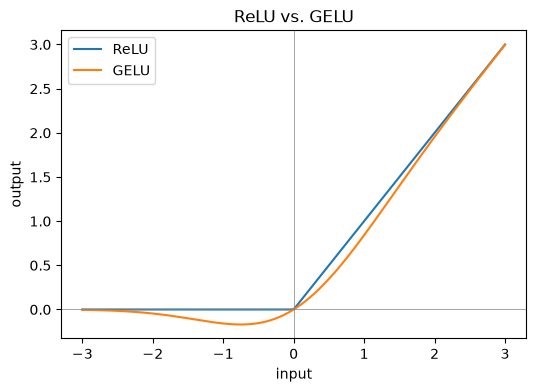

In [5]:
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 200)
relu_y = torch.relu(x)
gelu_y = torch.nn.functional.gelu(x)

plt.figure(figsize=(6, 4))
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, gelu_y, label="GELU")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.legend()
plt.title("ReLU vs. GELU")
plt.xlabel("input")
plt.ylabel("output")
plt.show()

Now the feed-forward network itself. GPT-2's design is simple: expand the embedding dimension by 4x with one linear layer, apply GELU, then project back down to the original size with a second linear layer. The "expand then contract" pattern gives the network a larger intermediate space to compute in before compressing back to the size every other part of the model expects.

In [6]:
class FeedForward(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.GELU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
        )

    def forward(self, x):
        return self.layers(x)

In [7]:
embedding_dim = 256
ff = FeedForward(embedding_dim)

dummy_input = torch.rand(2, 4, embedding_dim)  # (batch, num_tokens, embedding_dim)
output = ff(dummy_input)
print("Input shape: ", dummy_input.shape)
print("Output shape:", output.shape)  # same shape back out

Input shape:  torch.Size([2, 4, 256])
Output shape: torch.Size([2, 4, 256])


Same shape in, same shape out — exactly like `MultiHeadAttention`. Every piece of a transformer block is built to preserve `(batch, num_tokens, embedding_dim)`, which is precisely what lets us stack blocks arbitrarily deep.

## Ingredient 3: Residual (shortcut) connections

### The problem with very deep networks

As you stack more and more layers, gradients computed during backpropagation have to flow all the way from the output back to the earliest layers. Each layer they pass through can shrink them a little; after enough layers, the gradient reaching early layers can become vanishingly small — those layers barely get updated at all, and training effectively stalls. This is the **vanishing gradient problem**, and it gets worse the deeper the network is. GPT-2's smallest version stacks 12 transformer blocks; larger ones stack far more.

### The fix

A **residual connection** (also "skip connection" or "shortcut") simply adds a layer's *input* back to its *output*:

```
output = x + layer(x)
```

instead of just `output = layer(x)`. This creates a direct path for gradients to flow backward through the `+` operation, completely bypassing whatever transformation `layer` performs — addition passes gradients through unchanged to both of its inputs. Even if `layer(x)`'s own gradient path shrinks toward zero, the `+ x` path keeps a strong gradient signal reaching earlier layers.

Let's make this concrete with a small toy experiment: a 5-layer network, built two ways (with and without shortcuts), and compare the gradient magnitude that reaches each layer.

In [8]:
class ExampleDeepNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i + 1]), nn.GELU())
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output  # residual connection
            else:
                x = layer_output
        return x


def print_gradient_magnitudes(model, x):
    output = model(x)
    target = torch.tensor([[0.0]])
    loss = nn.functional.mse_loss(output, target)  # a dummy loss, just to trigger backward()
    loss.backward()  # computes gradients for every learnable parameter, via backpropagation

    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name}: mean absolute gradient = {param.grad.abs().mean().item():.6f}")

(`loss.backward()` is our first real look at PyTorch's **autograd** system, foreshadowed back in notebook 03: because every operation on a tensor was tracked, PyTorch can automatically compute how much each parameter contributed to the final loss — that's exactly what a "gradient" is. We'll build a full training loop around this in notebook 10; for now we're only using it as a probe to inspect gradient sizes.)

In [9]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1.0, 0.0, -1.0]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNetwork(layer_sizes, use_shortcut=False)
print("Without shortcut connections:")
print_gradient_magnitudes(model_without_shortcut, sample_input)

Without shortcut connections:
layers.0.0.weight: mean absolute gradient = 0.000202
layers.1.0.weight: mean absolute gradient = 0.000120
layers.2.0.weight: mean absolute gradient = 0.000715
layers.3.0.weight: mean absolute gradient = 0.001399
layers.4.0.weight: mean absolute gradient = 0.005050


In [10]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNetwork(layer_sizes, use_shortcut=True)
print("With shortcut connections:")
print_gradient_magnitudes(model_with_shortcut, sample_input)

With shortcut connections:
layers.0.0.weight: mean absolute gradient = 0.221868
layers.1.0.weight: mean absolute gradient = 0.207093
layers.2.0.weight: mean absolute gradient = 0.329239
layers.3.0.weight: mean absolute gradient = 0.266777
layers.4.0.weight: mean absolute gradient = 1.326806


Compare the earliest layer (`layers.0.0.weight`) in both printouts: without shortcuts, the gradient reaching the first layer is dramatically smaller than in later layers — it has nearly vanished by the time it propagates all the way back. With shortcuts, the gradient magnitudes stay much more consistent across all layers. That difference is exactly why residual connections are considered essential for training deep networks, transformers very much included.

## Assembling the `TransformerBlock`

Now we combine everything: `MultiHeadAttention` (notebook 06), `LayerNorm`, `FeedForward`, and residual connections around each of the two main sub-layers. GPT-2 uses "pre-norm" ordering — normalize *before* each sub-layer, not after:

```
x -> LayerNorm -> MultiHeadAttention -> Dropout -> (+ original x)
  -> LayerNorm -> FeedForward         -> Dropout -> (+ previous result)
```

Each sub-layer (attention, feed-forward) is wrapped in its own residual connection.

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attention_weights = torch.softmax(attention_scores / self.head_dim ** 0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)

        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)
        return self.out_proj(context_vectors)

In [12]:
class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, context_length, num_heads, dropout, qkv_bias=False):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=embedding_dim,
            d_out=embedding_dim,
            context_length=context_length,
            dropout=dropout,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
        )
        self.feed_forward = FeedForward(embedding_dim)
        self.norm1 = LayerNorm(embedding_dim)
        self.norm2 = LayerNorm(embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention sub-layer, with residual connection
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut

        # Feed-forward sub-layer, with residual connection
        shortcut = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = self.dropout(x)
        x = x + shortcut

        return x

In [13]:
torch.manual_seed(123)
transformer_block = TransformerBlock(
    embedding_dim=256, context_length=4, num_heads=4, dropout=0.1
)

dummy_input = torch.rand(2, 4, 256)  # (batch, num_tokens, embedding_dim)
output = transformer_block(dummy_input)

print("Input shape: ", dummy_input.shape)
print("Output shape:", output.shape)

Input shape:  torch.Size([2, 4, 256])
Output shape: torch.Size([2, 4, 256])


Same shape in, same shape out — `(2, 4, 256)` both times. This is the single repeating unit that gets stacked to build the full model.

## Recap

- **Layer normalization** rescales each token's features to mean 0, variance 1 (with learnable scale/shift), keeping activations well-behaved as they flow through many layers.
- A **feed-forward network** (`Linear -> GELU -> Linear`, expanding 4x in the middle) adds nonlinearity and per-token processing capacity that attention alone can't provide.
- **Residual connections** (`x + layer(x)`) give gradients a direct path backward through deep stacks of layers, preventing them from vanishing.
- A `TransformerBlock` combines multi-head attention and a feed-forward network, each wrapped in `LayerNorm` + residual connection, and preserves its input shape exactly — so it can be stacked as many times as we like.

### What's next

In notebook 08, we stack several `TransformerBlock`s together with the token/positional embeddings from notebook 04 and a final output layer, assembling the complete `GPTModel`.